In [1]:
import os
import random
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
)
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [2]:
def set_seed(seed: int = 101) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
set_seed()

In [3]:
df = pd.read_csv("web_traffic.csv")

In [4]:
df.head()

,timestamp,visits,avg_session_duration,server_load,support_tickets,error_rate
0,18362,95.0,2.281850,0.603946,1.670808,10.0
1,18363,91.0,2.257801,0.612456,1.715409,10.0
2,18364,89.0,2.234854,0.599669,1.748871,11.0
3,18365,85.0,2.169699,0.589510,NaN,11.0
4,18366,82.0,2.205969,0.572231,1.774709,11.0


In [5]:
### AUTOGRADED TASK
def convert_to_datetime(column: pd.Series) -> pd.Series:
    """
    Convert the values of the given `column` from days (`D`) since the epoch to `datetime64[ns]`.
    Return `column`.
    
    Note:
        Remove the `raise NotImplementedError()` line.
    """

    ### BEGIN SOLUTION
    column = pd.to_datetime(column, unit="D")
    ### END SOLUTION

    return column

In [6]:
### TEST
def test_convert_to_datetime():
    column = pd.Series([20000, 21000, 22000, 23000])
    column = convert_to_datetime(column)
    assert column.dtype == "<M8[ns]", "Make sure that the `dtype` is `datetime64[ns]`."
    assert column[0] == pd.Timestamp("2024-10-04"), "Make sure that the `unit` is correct."
    print("✔ Test passed!")
test_convert_to_datetime()
### BEGIN HIDDEN TESTS
def hidden_test_convert_to_datetime():
    column = pd.Series([20100, 21100, 22100, 23100])
    column = convert_to_datetime(column)
    assert column.dtype == "<M8[ns]", "Make sure that the `dtype` is `datetime64[ns]`."
    assert column[0] == pd.Timestamp("2025-01-12"), "Make sure that the `unit` is correct."
    print("✔ Test passed!")
hidden_test_convert_to_datetime()
### END HIDDEN TESTS

✔ Test passed!
✔ Test passed!


In [7]:
df["timestamp"] = convert_to_datetime(df["timestamp"])

In [8]:
df.head()

,timestamp,visits,avg_session_duration,server_load,support_tickets,error_rate
0,2020-04-10,95.0,2.281850,0.603946,1.670808,10.0
1,2020-04-11,91.0,2.257801,0.612456,1.715409,10.0
2,2020-04-12,89.0,2.234854,0.599669,1.748871,11.0
3,2020-04-13,85.0,2.169699,0.589510,NaN,11.0
4,2020-04-14,82.0,2.205969,0.572231,1.774709,11.0


In [9]:
df.set_index(keys=["timestamp"], drop=True, inplace=True)

In [10]:
df.head()

,visits,avg_session_duration,server_load,support_tickets,error_rate
timestamp,,,,,
2020-04-10,95.0,2.281850,0.603946,1.670808,10.0
2020-04-11,91.0,2.257801,0.612456,1.715409,10.0
2020-04-12,89.0,2.234854,0.599669,1.748871,11.0
2020-04-13,85.0,2.169699,0.589510,NaN,11.0
2020-04-14,82.0,2.205969,0.572231,1.774709,11.0


In [11]:
features = ["avg_session_duration", "server_load", "support_tickets", "error_rate"]
target = "visits"

In [12]:
df.isnull().sum()

visits                   0
avg_session_duration    26
server_load             34
support_tickets         37
error_rate              39
dtype: int64

In [13]:
### AUTOGRADED TASK
def impute_missing_values(column: pd.Series) -> pd.Series:
    """
    Impute the missing values in the given `column`
    using forward fill and backward fill (in the specified order).
    Return `column`.
    
    Note:
        Remove the `raise NotImplementedError()` line.
    """

    ### BEGIN SOLUTION
    column = column.ffill().bfill()
    ### END SOLUTION

    return column

In [14]:
### TEST
def test_impute_missing_values():
    column = pd.Series([np.nan, 2, np.nan, 4])
    column = impute_missing_values(column)
    assert column[0] == 2 and column[2] == 2, "Make sure you are using forward and backward fill for data imputation."
    print("✔ Test passed!")
test_impute_missing_values()
### BEGIN HIDDEN TESTS
def hidden_test_impute_missing_values():
    column = pd.Series([4, np.nan, 6, np.nan])
    column = impute_missing_values(column)
    assert column[1] == 4 and column[3] == 6, "Make sure you are using forward and backward fill for data imputation."
    print("✔ Test passed!")
hidden_test_impute_missing_values()
### END HIDDEN TESTS

✔ Test passed!
✔ Test passed!


In [15]:
for feature in features:
    df[feature] = impute_missing_values(df[feature])

In [16]:
df.isnull().sum()

visits                  0
avg_session_duration    0
server_load             0
support_tickets         0
error_rate              0
dtype: int64

In [17]:
### AUTOGRADED TASK
def calculate_simple_moving_average(column: pd.Series, column_name: str, window_size: int) -> pd.Series:
    """
    Calculate a Simple Moving Average (SMA) for the given `column` using a window size of `window_size`.
    SMA is the average of the last `window_size` points at each point in the time series.
    Return the SMA as `pd.Series` with name `{column_name}_sma_{window_size}`.

    Example:
        If `column = [10, 20, 30, 40, 50]` and `window_size = 3`, the SMA would be calculated as:
        [NaN, NaN, (10 + 20 + 30)/3, (20 + 30 + 40)/3, (30 + 40 + 50)/3] = [NaN, NaN, 20, 30, 40].
    
    Note:
        Remove the `raise NotImplementedError()` line.
    """

    ### BEGIN SOLUTION
    data = []
    for index in range(len(column)):
        if index + 1 >= window_size:
            data.append(column[(index + 1) - window_size:(index + 1)].mean())
        else:
            data.append(np.nan)
    series = pd.Series(data, name=f"{column_name}_sma_{window_size}")
    ### END SOLUTION

    return series

In [18]:
### TEST
def test_calculate_simple_moving_average():
    series = pd.Series([10, 20, 30, 40, 50])
    sma = calculate_simple_moving_average(series, "A", 3)
    assert pd.isna(sma[0]) and pd.isna(sma[1]) and sma[2] == 20. and sma[3] == 30. and sma[4] == 40., "The calculation is not correct."
    assert sma.name == "A_sma_3", "The name of the series is not correct."
    print("✔ Test passed!")
test_calculate_simple_moving_average()
### BEGIN HIDDEN TESTS
def hidden_test_calculate_simple_moving_average():
    series = pd.Series([60, 70, 80, 90, 100])
    sma = calculate_simple_moving_average(series, "B", 3)
    assert pd.isna(sma[0]) and pd.isna(sma[1]) and sma[2] == 70. and sma[3] == 80. and sma[4] == 90., "The calculation is not correct."
    assert sma.name == "B_sma_3", "The name of the series is not correct."
    print("✔ Test passed!")
hidden_test_calculate_simple_moving_average()
### END HIDDEN TESTS

✔ Test passed!
✔ Test passed!


In [19]:
for column_name in features + [target]:
    try:
        series = calculate_simple_moving_average(df[column_name], column_name, 3)
        df[series.name] = series.values
        features.append(series.name)
    except:
        pass
df.dropna(axis=0, inplace=True)

In [20]:
df.head()

,visits,avg_session_duration,server_load,support_tickets,error_rate,avg_session_duration_sma_3,server_load_sma_3,support_tickets_sma_3,error_rate_sma_3,visits_sma_3
timestamp,,,,,,,,,,
2020-04-12,89.0,2.234854,0.599669,1.748871,11.0,2.258168,0.605357,1.711696,10.333333,91.666667
2020-04-13,85.0,2.169699,0.589510,1.748871,11.0,2.220785,0.600545,1.737717,10.666667,88.333333
2020-04-14,82.0,2.205969,0.572231,1.774709,11.0,2.203507,0.587137,1.757484,11.000000,85.333333
2020-04-15,81.0,2.206981,0.556573,1.756915,11.0,2.194216,0.572772,1.760165,11.000000,82.666667
2020-04-16,81.0,2.186717,0.539052,1.719787,11.0,2.199889,0.555952,1.750470,11.000000,81.333333


In [21]:
### AUTOGRADED TASK
def create_lags(df: pd.DataFrame, features: list[str], target: str, num_lags: int) -> pd.DataFrame:
    """
    Generate lagged columns for each column (`features` and `target`), up to `num_lags`,
    within the given `df`.
    
    For each lag `k`, create new columns containing values
    shifted by `k` time steps into the past. Lagged columns are ordered
    chronologically from the most distant to the most recent lag, and the original
    column order is preserved within each lag.

    The name of the lagged columns follows the pattern `{column}_{lag}`.

    After creating the lagged columns, drop the original feature columns,
    keeping the original target column and the lagged columns.
    
    Finally, remove the rows with missing values.
    
    Note:
        Remove the `raise NotImplementedError()` line.
    """

    ### BEGIN SOLUTION
    lags = range(num_lags, 0, -1)
    for lag in lags:
        for column in features + [target]:
            df[f"{column}_{lag}"] = df[column].shift(lag)
    df.drop(columns=features, inplace=True)
    df.dropna(inplace=True)
    ### END SOLUTION

    return df

In [22]:
### TEST
def test_create_lags():
    df = pd.DataFrame(data=[[1, 2, 3], [4, 5, 6], [7, 8, 9], [10, 11, 23]], columns=["A", "B", "C"])
    df = create_lags(df, ["A", "B"], "C", 2)
    assert list(df.columns) == ["C", "A_2", "B_2", "C_2", "A_1", "B_1", "C_1"] or list(df.columns[1:]) == ["A_2", "B_2", "C_2", "A_1", "B_1", "C_1"], "The order of the columns is not correct."
    assert df["A_2"][2] == 1 and df["A_2"][3] == 4, "The shifting is not correct."
    assert df["A_1"][2] == 4 and df["A_1"][3] == 7, "The shifting is not correct."
    assert df["B_2"][2] == 2 and df["B_2"][3] == 5, "The shifting is not correct."
    assert df["B_1"][2] == 5 and df["B_1"][3] == 8, "The shifting is not correct."
    assert df["C_2"][2] == 3 and df["C_2"][3] == 6, "The shifting is not correct."
    assert df["C_1"][2] == 6 and df["C_1"][3] == 9, "The shifting is not correct."
    assert all([feature not in list(df.columns) for feature in ["A", "B"]]), "The features columns are not dropped."
    assert df.isnull().sum().sum().item() == 0, "The rows with missing values are not removed."
    print("✔ Test passed!")
test_create_lags()

✔ Test passed!


In [23]:
num_lags = 5

In [24]:
df = create_lags(df, features, target, num_lags)

In [25]:
X, y = df.drop(columns=target), df[[target]]

In [26]:
### AUTOGRADED TASK
def generate_train_val_test_split(X: pd.DataFrame, y: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Generate `train_X`, `val_X`, `test_X`, `train_y`, `val_y`, and `test_y` from the given `df`.
    The ratio of train, validation, and test is 80:10:10.
    First split `df` in train and test, then further split the test into test and validation.
    Set `random_state=42` to ensure reproducibility.
    
    Note:
        Remove the `raise NotImplementedError()` line.
    """

    ### BEGIN SOLUTION
    train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, shuffle=False, random_state=42)
    test_X, val_X, test_y, val_y = train_test_split(test_X, test_y, test_size=0.5, shuffle=False, random_state=42)
    ### END SOLUTION

    return train_X, val_X, test_X, train_y, val_y, test_y

In [27]:
### TEST
def test_generate_train_val_test_split():
    df = pd.DataFrame([[1, 2], [3, 4], [5, 6], [7, 8], [9, 10], [11, 12], [13, 14], [15, 16], [17, 18], [19, 20]])
    X, y = df[[0]], df[[1]]
    train_X, val_X, test_X, train_y, val_y, test_y = generate_train_val_test_split(X, y)
    assert train_X.shape[0] == 8 and train_y.shape[0] == 8, "The shape of the train dataset is not correct."
    assert val_X.shape[0] == 1 and val_y.shape[0] == 1, "The shape of the validation dataset is not correct."
    assert test_X.shape[0] == 1 and test_y.shape[0] == 1, "The shape of the test dataset is not correct."
    print("✔ Test passed!")
test_generate_train_val_test_split()

✔ Test passed!


In [28]:
train_X, val_X, test_X, train_y, val_y, test_y = generate_train_val_test_split(X, y)

In [29]:
### AUTOGRADED TASK
def reshape_features(train_X: pd.DataFrame, val_X: pd.DataFrame, test_X: pd.DataFrame, num_lags: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Reshape `train_X`, `val_X`, `test_X` into a shape of (num_samples, num_lags, num_features).
    Return `train_X`, `val_X`, and `test_X`.
    
    Note:
        Remove the `raise NotImplementedError()` line.
    """

    ### BEGIN SOLUTION
    train_X = train_X.reshape(train_X.shape[0], num_lags, (train_X.shape[1] // num_lags))
    val_X = val_X.reshape(val_X.shape[0], num_lags, (val_X.shape[1] // num_lags))
    test_X = test_X.reshape(test_X.shape[0], num_lags, (test_X.shape[1] // num_lags))
    ### END SOLUTION

    return train_X, val_X, test_X

In [30]:
### TEST
def test_reshape_features():
    train_X = np.array([[1, 2, 3, 4, 5, 6], [7, 8, 9, 10, 11, 12], [13, 14, 15, 16, 17, 18], [19, 20, 21, 22, 23, 24]])
    val_X = np.array([[1, 2, 3, 4, 5, 6], [7, 8, 9, 10, 11, 12]])
    test_X = np.array([[1, 2, 3, 4, 5, 6], [7, 8, 9, 10, 11, 12]])
    train_X, val_X, test_X = reshape_features(train_X, val_X, test_X, 2)
    assert train_X.shape[0] == 4 and train_X.shape[1] == 2 and train_X.shape[2] == 3, "The shape of the train dataset is not correct."
    assert val_X.shape[0] == 2 and val_X.shape[1] == 2 and val_X.shape[2] == 3, "The shape of the validation dataset is not correct."
    assert test_X.shape[0] == 2 and test_X.shape[1] == 2 and test_X.shape[2] == 3, "The shape of the test dataset is not correct."
    print("✔ Test passed!")
test_reshape_features()

✔ Test passed!


In [31]:
train_X, val_X, test_X = reshape_features(train_X.to_numpy(), val_X.to_numpy(), test_X.to_numpy(), num_lags)

In [32]:
train_X = torch.tensor(train_X, dtype=torch.float32)
train_y = torch.tensor(train_y.to_numpy(), dtype=torch.float32)

val_X = torch.tensor(val_X, dtype=torch.float32)
val_y = torch.tensor(val_y.to_numpy(), dtype=torch.float32)

test_X = torch.tensor(test_X, dtype=torch.float32)
test_y = torch.tensor(test_y.to_numpy(), dtype=torch.float32)

In [33]:
train_dataset = TensorDataset(train_X, train_y)
val_dataset = TensorDataset(val_X, val_y)
test_dataset = TensorDataset(test_X, test_y)

In [34]:
### AUTOGRADED TASK
def create_data_loader(dataset: TensorDataset) -> DataLoader:
    """
    Create a data loader for the given dataset with a batch size of 32.
    Return `data_loader`.

    Note:
        Remove the `raise NotImplementedError()` line.
    """
    ### BEGIN SOLUTION
    data_loader = DataLoader(dataset, batch_size=32, shuffle=False)
    ### END SOLUTION

    return data_loader

In [35]:
### TEST
def test_create_data_loader():
    X = torch.randn(100, 10)
    y = torch.randint(0, 2, (100,))
    dataset = TensorDataset(X, y)
    data_loader = create_data_loader(dataset)
    assert data_loader.batch_size == 32 and isinstance(data_loader.sampler, torch.utils.data.SequentialSampler), "The data loader is not configured properly."
    print("✔ Test passed!")
test_create_data_loader()

✔ Test passed!


In [36]:
train_loader = create_data_loader(train_dataset)
val_loader = create_data_loader(val_dataset)
test_loader = create_data_loader(test_dataset)

In [37]:
class Regressor(nn.Module):
    """
    A class for a CNN regression model.

    IMPORTANT: The constructor MUST have a `num_features` argument.
    Implement both the `__init__` and `forward` methods.

    The model should consist of the following layers:
        - a 1D convolutional layer (`conv1`) with 32 filters, a kernel of size 4, a padding of 2, and ReLU activation function;
        - a 1D average pooling layer (`pool1`) with a kernel size of 2;
        - a 1D convolutional layer (`conv2`) with 64 filters, a kernel of size 4, a padding of 2, and ReLU activation function;
        - a 1D average pooling layer (`pool2`) with a kernel size of 2;
        - a flattening layer (`flatten`),
        - a fully connected layer (`fc`) with 1 neuron.
        
    Note:
        Remove the `raise NotImplementedError()` line.
    """
    ### BEGIN SOLUTION
    def __init__(self, num_features):
        super().__init__()
        self.conv1 = nn.Conv1d(num_features, 32, kernel_size=4, padding=2)
        self.pool1 = nn.AvgPool1d(2)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=4, padding=2)
        self.pool2 = nn.AvgPool1d(2)

        self.flatten = nn.Flatten()

        self.fc = nn.Linear(128, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)

        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))

        x = x.permute(0, 2, 1)

        x = self.flatten(x)

        return self.fc(x)
    ### END SOLUTION

In [38]:
### TEST
def test_regressor_1():
    model = Regressor(num_features=2)
    assert hasattr(model, "conv1")
    assert isinstance(model.conv1, nn.Conv1d)
    assert hasattr(model.conv1, "in_channels") and model.conv1.in_channels == 2
    assert hasattr(model.conv1, "out_channels") and model.conv1.out_channels == 32
    assert hasattr(model.conv1, "kernel_size") and model.conv1.kernel_size[0] == 4
    assert hasattr(model.conv1, "padding") and model.conv1.padding[0] == 2
    print("✔ Test passed!")
test_regressor_1()

✔ Test passed!


In [39]:
### TEST
def test_regressor_2():
    model = Regressor(num_features=2)
    assert hasattr(model, "pool1")
    assert isinstance(model.pool1, nn.AvgPool1d)
    assert hasattr(model.pool1, "kernel_size") and model.pool1.kernel_size[0] == 2
    print("✔ Test passed!")
test_regressor_2()

✔ Test passed!


In [40]:
### TEST
def test_regressor_3():
    model = Regressor(num_features=2)
    assert hasattr(model, "conv2")
    assert isinstance(model.conv2, nn.Conv1d)
    assert hasattr(model.conv2, "in_channels") and model.conv2.in_channels == 32
    assert hasattr(model.conv2, "out_channels") and model.conv2.out_channels == 64
    assert hasattr(model.conv2, "kernel_size") and model.conv2.kernel_size[0] == 4
    assert hasattr(model.conv2, "padding") and model.conv2.padding[0] == 2
    print("✔ Test passed!")
test_regressor_3()

✔ Test passed!


In [41]:
### TEST
def test_regressor_4():
    model = Regressor(num_features=2)
    assert hasattr(model, "pool2")
    assert isinstance(model.pool2, nn.AvgPool1d)
    assert hasattr(model.pool2, "kernel_size") and model.pool2.kernel_size[0] == 2
    print("✔ Test passed!")
test_regressor_4()

✔ Test passed!


In [42]:
### TEST
def test_regressor_5():
    model = Regressor(num_features=2)
    assert hasattr(model, "flatten")
    assert isinstance(model.flatten, nn.Flatten)
    print("✔ Test passed!")
test_regressor_5()

✔ Test passed!


In [43]:
### TEST
def test_regressor_6():
    model = Regressor(num_features=2)
    x = torch.rand((10, 7, 2))
    model(x)
    print("✔ Test passed!")
test_regressor_6()

✔ Test passed!


In [44]:
num_features = len(features + [target])
model = Regressor(num_features)

In [45]:
### AUTOGRADED TASK
def define_loss_fn_and_optimizer():
    """
    Define an appropriate loss_fn and an Adam optimizer with a learning rate of 0.003.
    Return `loss_fn` and `optimizer`.

    Note:
        Remove the `raise NotImplementedError()` line.
    """
    ### BEGIN SOLUTION
    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=3e-3)
    ### END SOLUTION

    return loss_fn, optimizer

In [46]:
### TEST
def test_define_loss_fn_and_optimizer():
    true_y = torch.tensor([1, 2, 3], dtype=torch.float32)
    pred_y = torch.tensor([1, 4, 3], dtype=torch.float32)
    loss_fn, optimizer = define_loss_fn_and_optimizer()
    assert round(loss_fn(true_y, pred_y).item(), 2) == 1.33
    assert optimizer.param_groups[0]["lr"] == 3e-3
    print("✔ Test passed!")
test_define_loss_fn_and_optimizer()

✔ Test passed!


In [47]:
loss_fn, optimizer = define_loss_fn_and_optimizer()

In [48]:
def train(model, dataloader, loss_fn, optimizer):
    model.train()

    total_loss = 0
    for features, targets in dataloader:
        features, targets = features, targets

        optimizer.zero_grad()

        outputs = model(features)
        loss = loss_fn(outputs, targets)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    return total_loss / len(dataloader)

In [49]:
def evaluate(model, dataloader, loss_fn):
    model.eval()

    total_loss, predictions = 0, []
    with torch.no_grad():
        for features, targets in dataloader:
            features, targets = features, targets

            outputs = model(features)
            loss = loss_fn(outputs, targets)

            predictions.extend(outputs.tolist())
            
            total_loss += loss.item()

    return total_loss / len(dataloader), predictions

In [50]:
num_epochs = 16

In [51]:
def train_and_evaluate(model, train_loader, val_loader, loss_fn, optimizer, num_epochs):
    train_losses, val_losses = [], []
    for epoch in range(1, num_epochs + 1):
        train_loss = train(model, train_loader, loss_fn, optimizer)
        train_losses.append(train_loss)
        val_loss, pred_y = evaluate(model, val_loader, loss_fn)
        val_losses.append(val_loss)

        val_mape = mean_absolute_percentage_error(val_y.tolist(), pred_y)

        print(f"Epoch {epoch:3d}/{num_epochs} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_mape={val_mape:.4f}")
    
    return train_losses, val_losses

In [52]:
train_losses, val_losses = train_and_evaluate(model, train_loader, val_loader, loss_fn, optimizer, num_epochs)

Epoch   1/16 | train_loss=1352.9131 val_loss=171.3655 val_mape=0.1207
Epoch   2/16 | train_loss=97.2150 val_loss=162.7830 val_mape=0.1161
Epoch   3/16 | train_loss=88.7281 val_loss=155.5317 val_mape=0.1111
Epoch   4/16 | train_loss=84.7296 val_loss=148.0555 val_mape=0.1078
Epoch   5/16 | train_loss=84.5291 val_loss=143.9887 val_mape=0.1052
Epoch   6/16 | train_loss=81.7278 val_loss=146.8832 val_mape=0.1046
Epoch   7/16 | train_loss=75.7713 val_loss=156.1449 val_mape=0.1050
Epoch   8/16 | train_loss=67.3665 val_loss=161.4204 val_mape=0.1060
Epoch   9/16 | train_loss=57.6411 val_loss=145.9918 val_mape=0.1018
Epoch  10/16 | train_loss=47.3625 val_loss=111.1311 val_mape=0.0906
Epoch  11/16 | train_loss=37.2572 val_loss=74.5351 val_mape=0.0763
Epoch  12/16 | train_loss=28.6142 val_loss=44.9309 val_mape=0.0611
Epoch  13/16 | train_loss=22.1888 val_loss=28.6976 val_mape=0.0494
Epoch  14/16 | train_loss=16.4074 val_loss=18.6750 val_mape=0.0398
Epoch  15/16 | train_loss=12.5475 val_loss=15.6560

<Axes: >

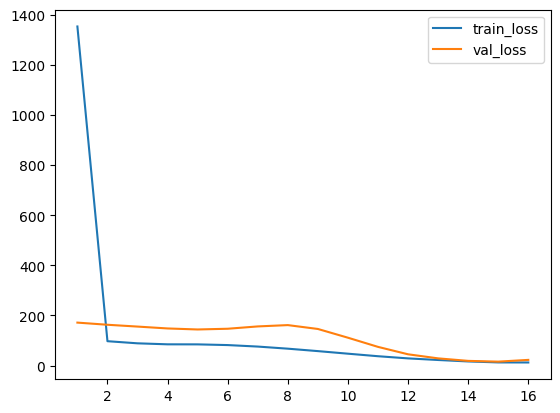

In [53]:
sns.lineplot(x=range(1, num_epochs + 1), y=train_losses, label="train_loss")
sns.lineplot(x=range(1, num_epochs + 1), y=val_losses, label="val_loss")

In [54]:
test_loss, pred_y = evaluate(model, test_loader, loss_fn)

In [55]:
print(f"MAE: {mean_absolute_error(test_y, pred_y)}")
print(f"MAPE: {mean_absolute_percentage_error(test_y, pred_y)}")
print(f"MSE: {mean_squared_error(test_y, pred_y)}")
print(f"RMSE: {root_mean_squared_error(test_y, pred_y)}")
print(f"R2 Score: {r2_score(test_y, pred_y)}")

MAE: 2.2734570284502222
MAPE: 0.02823675667495943
MSE: 8.204123340169803
RMSE: 2.8642840885934837
R2 Score: 0.9221595692785269


In [56]:
### TEST
assert r2_score(test_y, pred_y) > 0.85
print("✔ Test passed!")

✔ Test passed!
